# **📞 Customer Churn Prediction — A Business Problem**


Customer churn is a real business problem: when customers leave, companies lose revenue and need to replace them. In this project, I explore the **Telco Customer Churn** dataset and build two classification models:

- 🌳 Decision Tree Classifier
- 📈 Logistic Regression

The goal is to combine **machine learning with business understanding**.

## 1. Import Libraries
We import tools for data handling, visualization, preprocessing, modeling and evaluation.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid')

## 2. Load the Dataset
The Dataset is loaded into Pandas. `TotalCharges` is converted to numeric because blank entries can otherwise be treated as text.

In [2]:
from google.colab import files
uploaded = files.upload()
df = pd.read_csv('Telco-Customer-Churn.csv')
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

print("Rows:", df.shape[0])
print("Columns:", df.shape[1])
df.head()

Saving Telco-Customer-Churn.csv to Telco-Customer-Churn.csv
Rows: 7043
Columns: 21


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


### 📌 Interpretation
The dataset contains customer information such as tenure, contract, payment method, monthly charges and churn status. The preview confirms the data is ready for EDA.

## 3. Dataset Overview

In [3]:
df.info()

print("\nSummary statistics:")
display(df.describe(include='all').T)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
customerID,7043,7043,3186-AJIEK,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gender,7043,2,Male,3555,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SeniorCitizen,7043.0,NaN,NaN,NaN,0.162147,0.368612,0.0,0.0,0.0,0.0,1.0
Partner,7043,2,No,3641,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Dependents,7043,2,No,4933,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tenure,7043.0,NaN,NaN,NaN,32.371149,24.559481,0.0,9.0,29.0,55.0,72.0
PhoneService,7043,2,Yes,6361,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MultipleLines,7043,3,No,3390,NaN,NaN,NaN,NaN,NaN,NaN,NaN
InternetService,7043,3,Fiber optic,3096,NaN,NaN,NaN,NaN,NaN,NaN,NaN
OnlineSecurity,7043,3,No,3498,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### 📌 Interpretation
The dataset contains both numerical and categorical variables. `TotalCharges` may contain missing values after conversion, so we check missing data next.

## 4. Missing Values

In [4]:
missing = df.isnull().sum().sort_values(ascending=False)
display(missing[missing > 0])

,0
TotalCharges,11


### 📌 Interpretation
Missing values are handled later inside the preprocessing pipeline. This avoids unnecessarily deleting customer records.

## 5. Churn Distribution

In [5]:
churn_counts = df['Churn'].value_counts()
display(churn_counts)
display((df['Churn'].value_counts(normalize=True) * 100).round(2))

,count
Churn,
No,5174
Yes,1869


,proportion
Churn,
No,73.46
Yes,26.54


### 📌 Class Imbalance Note
The churn classes are not perfectly balanced. Therefore, accuracy alone may not tell the complete story. Precision, Recall and F1-score will also be used to evaluate the models.

## 6. Quick EDA — Contract Type and Churn

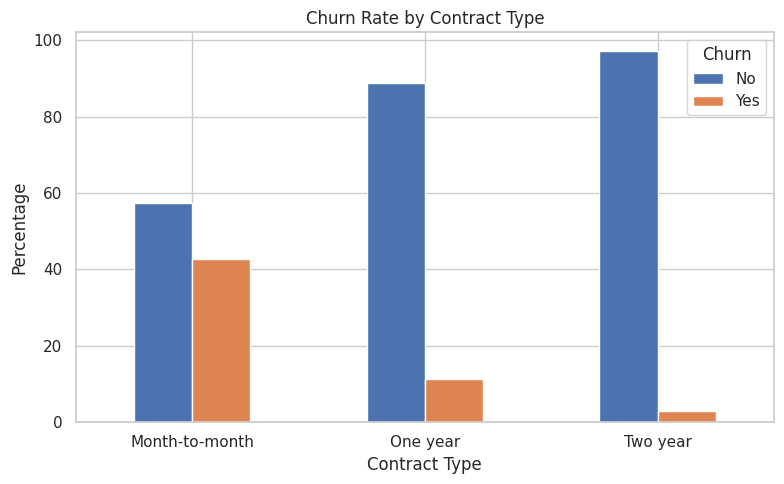

In [6]:
contract_churn = pd.crosstab(df['Contract'], df['Churn'], normalize='index') * 100
contract_churn.plot(kind='bar', figsize=(8,5))
plt.title('Churn Rate by Contract Type')
plt.xlabel('Contract Type')
plt.ylabel('Percentage')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### 📌 Interpretation
This chart compares churn across contract types. Clear differences suggest contract type can be useful for understanding retention behavior.

## 7. Quick EDA — Tenure and Churn

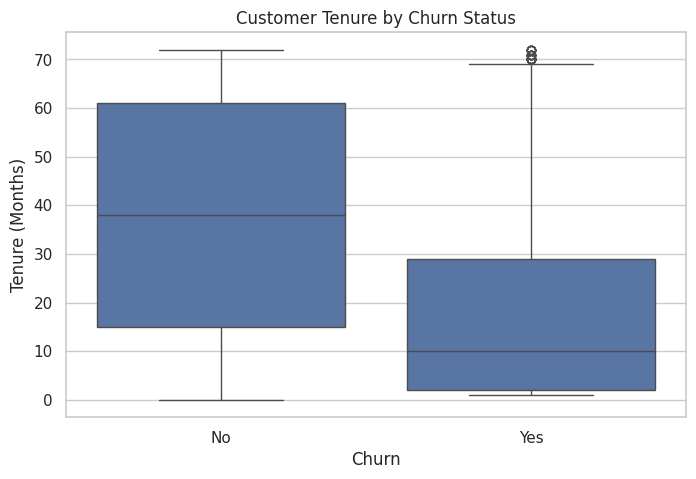

In [7]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x='Churn', y='tenure')
plt.title('Customer Tenure by Churn Status')
plt.xlabel('Churn')
plt.ylabel('Tenure (Months)')
plt.show()

### 📌 Interpretation
The boxplot compares how long customers stayed with the company. Differences between the groups can help identify whether newer or longer-term customers are more likely to churn.

## 8. Quick EDA — Monthly Charges and Churn

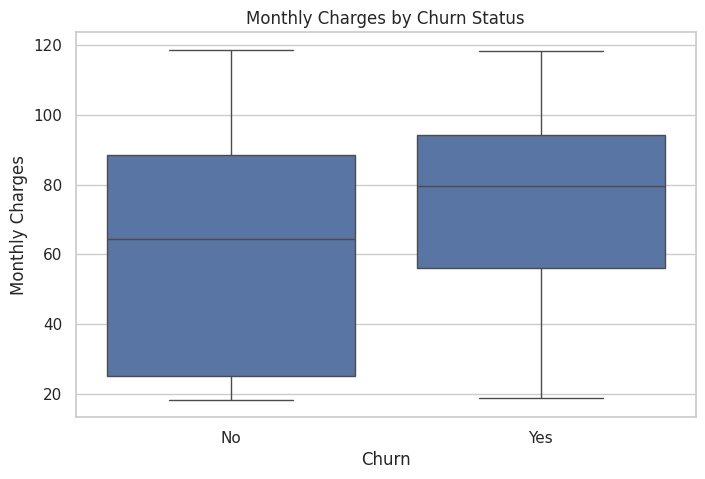

In [8]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x='Churn', y='MonthlyCharges')
plt.title('Monthly Charges by Churn Status')
plt.xlabel('Churn')
plt.ylabel('Monthly Charges')
plt.show()

### 📌 Interpretation
This comparison shows whether monthly charges differ between customers who stay and customers who leave.

## 9. Prepare Features
We remove `customerID` because it is an identifier, not a useful behavioral predictor. Categorical variables will be one-hot encoded.

In [9]:
X = df.drop(columns=['customerID', 'Churn'])
y = df['Churn'].map({'No': 0, 'Yes': 1})

numeric_features = X.select_dtypes(include=['int64','float64']).columns.tolist()
categorical_features = X.select_dtypes(include=['object']).columns.tolist()

print("Numerical features:", numeric_features)
print("Categorical features:", categorical_features)

Numerical features: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']
Categorical features: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


### 📌 Interpretation
The target is converted from `No/Yes` into `0/1`. The predictors are divided into numerical and categorical groups for preprocessing.

## 10. Preprocessing Pipeline

In [10]:
numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median'))
])

categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer([
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])

### 📌 Interpretation
Numerical missing values use the median, categorical missing values use the most frequent category, and categorical features are converted into numerical columns.

## 11. Train-Test Split

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)
print("Training records:", len(X_train))
print("Testing records:", len(X_test))

Training records: 5634
Testing records: 1409


### 📌 Interpretation
The model learns from the training data and is evaluated on unseen test data. Stratification keeps the churn proportions similar in both sets.

## 12. Decision Tree Classifier

In [12]:
decision_tree = Pipeline([
    ('preprocessor', preprocessor),
    ('model', DecisionTreeClassifier(max_depth=5, random_state=42))
])

decision_tree.fit(X_train, y_train)
dt_pred = decision_tree.predict(X_test)

### 📌 Interpretation
The Decision Tree learns a set of rules that separates customers likely to churn from customers likely to stay.

## 13. Logistic Regression

In [13]:
logistic_model = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(max_iter=2000))
])

logistic_model.fit(X_train, y_train)
lr_pred = logistic_model.predict(X_test)

/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


### 📌 Interpretation
Logistic Regression estimates the probability of churn based on customer characteristics. It provides a useful comparison with the tree model.

## 14. Compare Model Performance

In [14]:
def evaluate_model(name, y_true, pred):
    return {
        'Model': name,
        'Accuracy': accuracy_score(y_true, pred),
        'Precision': precision_score(y_true, pred, zero_division=0),
        'Recall': recall_score(y_true, pred, zero_division=0),
        'F1-score': f1_score(y_true, pred, zero_division=0)
    }

results = pd.DataFrame([
    evaluate_model('Decision Tree', y_test, dt_pred),
    evaluate_model('Logistic Regression', y_test, lr_pred)
])

display(results.round(4))

print("Decision Tree Classification Report:")
print(classification_report(y_test, dt_pred, zero_division=0))

print("\nLogistic Regression Classification Report:")
print(classification_report(y_test, lr_pred, zero_division=0))

,Model,Accuracy,Precision,Recall,F1-score
0,Decision Tree,0.7984,0.6347,0.5668,0.5989
1,Logistic Regression,0.8070,0.6604,0.5615,0.6069


Decision Tree Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.88      0.87      1035
           1       0.63      0.57      0.60       374

    accuracy                           0.80      1409
   macro avg       0.74      0.72      0.73      1409
weighted avg       0.79      0.80      0.79      1409


Logistic Regression Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.90      0.87      1035
           1       0.66      0.56      0.61       374

    accuracy                           0.81      1409
   macro avg       0.76      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409



### 📌 Interpretation
The table compares both models using four metrics. Because the churn classes are not perfectly balanced, F1-score, Precision and Recall are important alongside accuracy.

## 15. Confusion Matrices

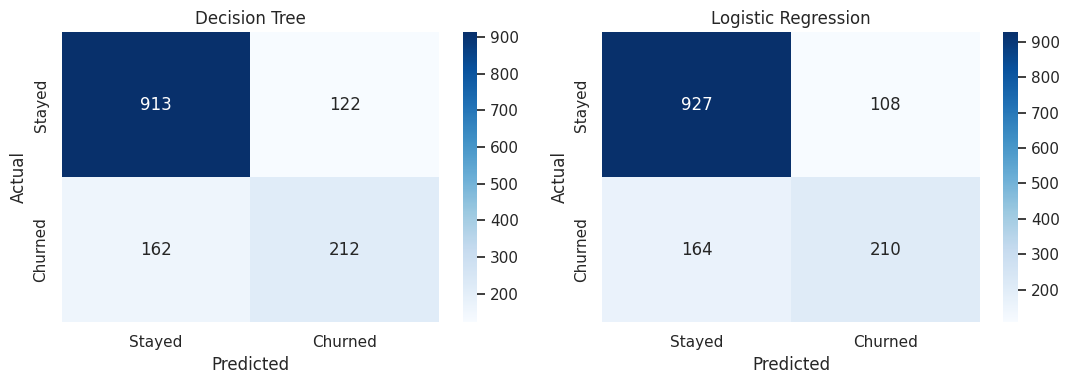

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(11,4))

for ax, (name, pred) in zip(axes, [('Decision Tree', dt_pred), ('Logistic Regression', lr_pred)]):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Stayed','Churned'],
                yticklabels=['Stayed','Churned'], ax=ax)
    ax.set_title(name)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.show()

### 📌 Interpretation
The confusion matrices show exactly where each model is correct and where it makes mistakes. False negatives are especially important in churn prediction because they represent customers who actually leave but were not flagged.

## 16. Top 3 Churn Features — Decision Tree

In [16]:
fitted_preprocessor = decision_tree.named_steps['preprocessor']
fitted_tree = decision_tree.named_steps['model']

feature_names = fitted_preprocessor.get_feature_names_out()
importances = fitted_tree.feature_importances_

feature_importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values('Importance', ascending=False)

top_3 = feature_importance.head(3)

print("Top 3 features driving churn according to the Decision Tree:")
display(top_3.round(4))

Top 3 features driving churn according to the Decision Tree:


,Feature,Importance
36,cat__Contract_Month-to-month,0.5140
16,cat__InternetService_Fiber optic,0.1633
1,num__tenure,0.1567


### 📌 Interpretation
These are the three features that contributed most to the Decision Tree's predictive decisions. Feature importance indicates predictive usefulness; it does not prove that a feature directly causes churn.

## 17. Visualize Top 3 Features

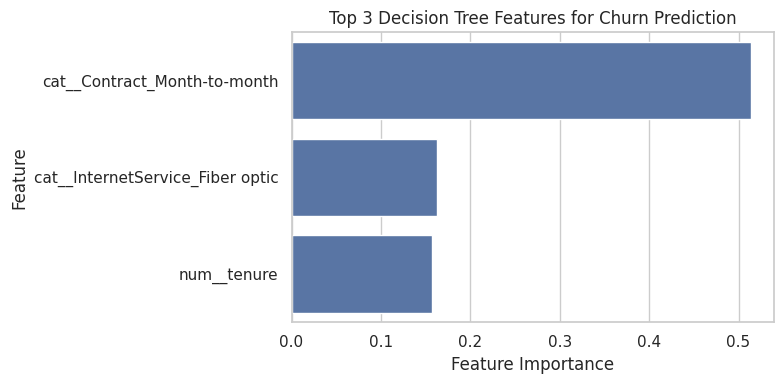

In [17]:
plt.figure(figsize=(8,4))
sns.barplot(data=top_3, x='Importance', y='Feature')
plt.title('Top 3 Decision Tree Features for Churn Prediction')
plt.xlabel('Feature Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

### 📌 Interpretation
The chart makes the three strongest tree features easier to communicate to a business audience.

# 💼 Business Summary

The analysis shows that customer churn is linked to differences in customer characteristics such as contract type, tenure and monthly charges. The Decision Tree and Logistic Regression models provide practical ways to identify customers who may be at higher risk of leaving. The Decision Tree's top three features can help the business focus retention efforts on the customer characteristics most useful for prediction. Because the churn classes are not perfectly balanced, Precision, Recall and F1-score should be considered alongside accuracy. These predictions should be treated as risk signals that support retention decisions, not as certainty that a customer will leave.

# ✅ General Conclusion

This project turned a real customer-retention problem into a complete machine learning workflow. After quick EDA, missing values and categorical variables were handled through a preprocessing pipeline, and Decision Tree and Logistic Regression models were trained and compared.

The Decision Tree was also used to identify the top three predictive features through `feature_importances_`. The main lesson is that machine learning can do more than predict churn — it can help businesses understand customer patterns and make more targeted retention decisions.

**Good machine learning connects model performance with a real business question.**